# E-Commerce Product Recommendation System — EDA

## Business Problem
In e-commerce, customers are exposed to thousands of products but only have time to browse a fraction.
A recommendation system solves this by predicting which products a specific user is most likely to
purchase or rate highly, based on their past behaviour and the behaviour of similar users.

This increases:
- **Revenue** — users discover and buy more products
- **Engagement** — personalised experience keeps users on platform longer
- **Retention** — users return because the platform 'understands' their taste

Amazon attributes ~35% of its revenue to its recommendation engine.

**Approaches we will implement:**
1. Content-Based Filtering — recommend based on product features
2. Collaborative Filtering (User-User & Item-Item) — recommend based on user similarity
3. Matrix Factorization (SVD) — latent factor model

**Dataset:** Amazon Product Ratings Dataset from Kaggle
- URL: https://www.kaggle.com/datasets/skillsmuggler/amazon-ratings
- Download `ratings_Beauty.csv` and save as `../data/ratings.csv`
- Columns: userId, productId, rating, timestamp

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('C:\\Users\\hp\\Documents\\Projects\\E-Commerce Product Recommendation System\\data\\ratings_Beauty.csv',
                 names=['userId', 'productId', 'rating', 'timestamp'])
print('Shape:', df.shape)
df.head()

Shape: (2023071, 4)


,userId,productId,rating,timestamp
0,UserId,ProductId,Rating,Timestamp
1,A39HTATAQ9V7YF,0205616461,5.0,1369699200
2,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
3,A1Z513UWSAAO0F,0558925278,5.0,1404691200
4,A1WMRR494NWEWV,0733001998,4.0,1382572800


## 1. Dataset Overview

In [3]:
print(df['rating'].dtype)

object


In [4]:
import pandas as pd

# Convert rating column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

print('Total ratings: ', len(df))
print('Unique users: ', df['userId'].nunique())
print('Unique products: ', df['productId'].nunique())

print('Rating range: ', df['rating'].min(), '-', df['rating'].max())

print('Avg rating: ', round(df['rating'].mean(), 2))

print(
    'Sparsity:',
    round(
        1 - len(df) /
        (df['userId'].nunique() * df['productId'].nunique()),
        5
    )
)

Total ratings:  2023071
Unique users:  1210272
Unique products:  249275
Rating range:  1.0 - 5.0
Avg rating:  4.15
Sparsity: 0.99999


## 2. Rating Distribution
Understanding how users rate helps us interpret model outputs.

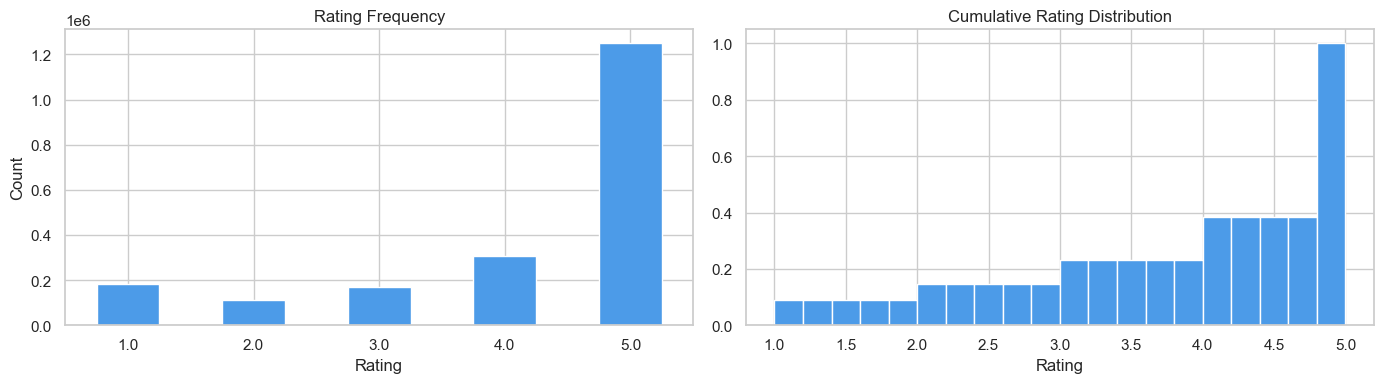

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating frequency
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='#4C9BE8', edgecolor='white')
axes[0].set_title('Rating Frequency')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Cumulative distribution
df['rating'].hist(bins=20, ax=axes[1], color='#4C9BE8', edgecolor='white', cumulative=True, density=True)
axes[1].set_title('Cumulative Rating Distribution')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

## 3. Ratings per User — Long Tail Distribution

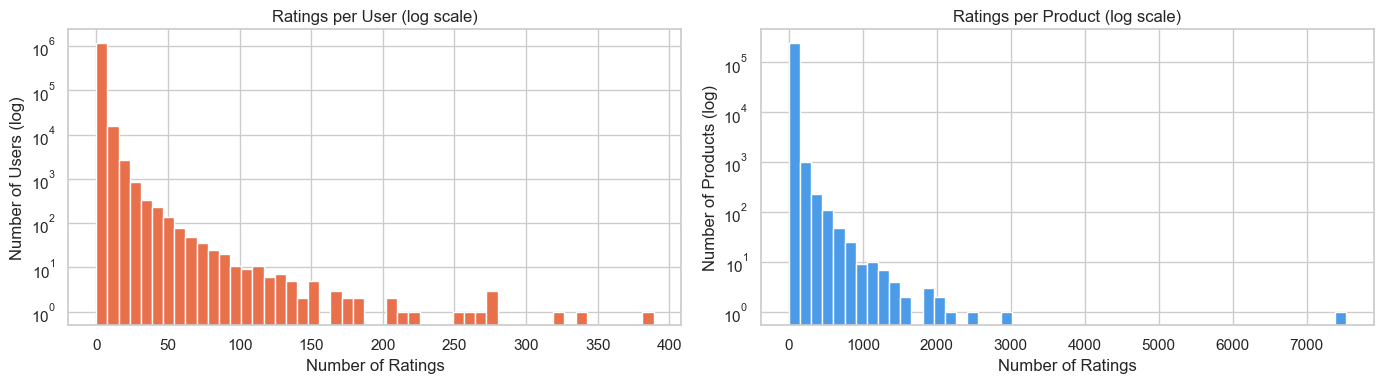

Users with only 1 rating:    887401
Products with only 1 rating: 103484

Top 10 most-rated products:
productId
B001MA0QY2    7533
B0009V1YR8    2869
B0043OYFKU    2477
B0000YUXI0    2143
B003V265QW    2088
B000ZMBSPE    2041
B003BQ6QXK    1918
B004OHQR1Q    1885
B00121UVU0    1838
B000FS05VG    1589
Name: rating, dtype: int64


In [7]:
ratings_per_user = df.groupby('userId')['rating'].count()
ratings_per_product = df.groupby('productId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings_per_user, bins=50, color='#E8714C', edgecolor='white', log=True)
axes[0].set_title('Ratings per User (log scale)')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users (log)')

axes[1].hist(ratings_per_product, bins=50, color='#4C9BE8', edgecolor='white', log=True)
axes[1].set_title('Ratings per Product (log scale)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Products (log)')

plt.tight_layout()
plt.show()

print('Users with only 1 rating:   ', (ratings_per_user == 1).sum())
print('Products with only 1 rating:', (ratings_per_product == 1).sum())
print('\nTop 10 most-rated products:')
print(ratings_per_product.sort_values(ascending=False).head(10))

## 4. Filtering for Quality — Cold Start Handling

In [8]:
# Keep only users with >= 5 ratings and products with >= 10 ratings
# This reduces sparsity and cold start issues
min_user_ratings    = 5
min_product_ratings = 10

user_counts    = df['userId'].value_counts()
product_counts = df['productId'].value_counts()

df_filtered = df[
    df['userId'].isin(user_counts[user_counts >= min_user_ratings].index) &
    df['productId'].isin(product_counts[product_counts >= min_product_ratings].index)
].copy()

print('Original shape: ', df.shape)
print('Filtered shape: ', df_filtered.shape)
print('Users kept:     ', df_filtered['userId'].nunique())
print('Products kept:  ', df_filtered['productId'].nunique())

# Save filtered dataset
df_filtered.to_csv('../data/ratings_filtered.csv', index=False)
print('\nFiltered dataset saved to ../data/ratings_filtered.csv')

Original shape:  (2023071, 4)
Filtered shape:  (350229, 4)
Users kept:      51888
Products kept:   34818

Filtered dataset saved to ../data/ratings_filtered.csv


## 5. User-Item Matrix — Sparsity Visualisation

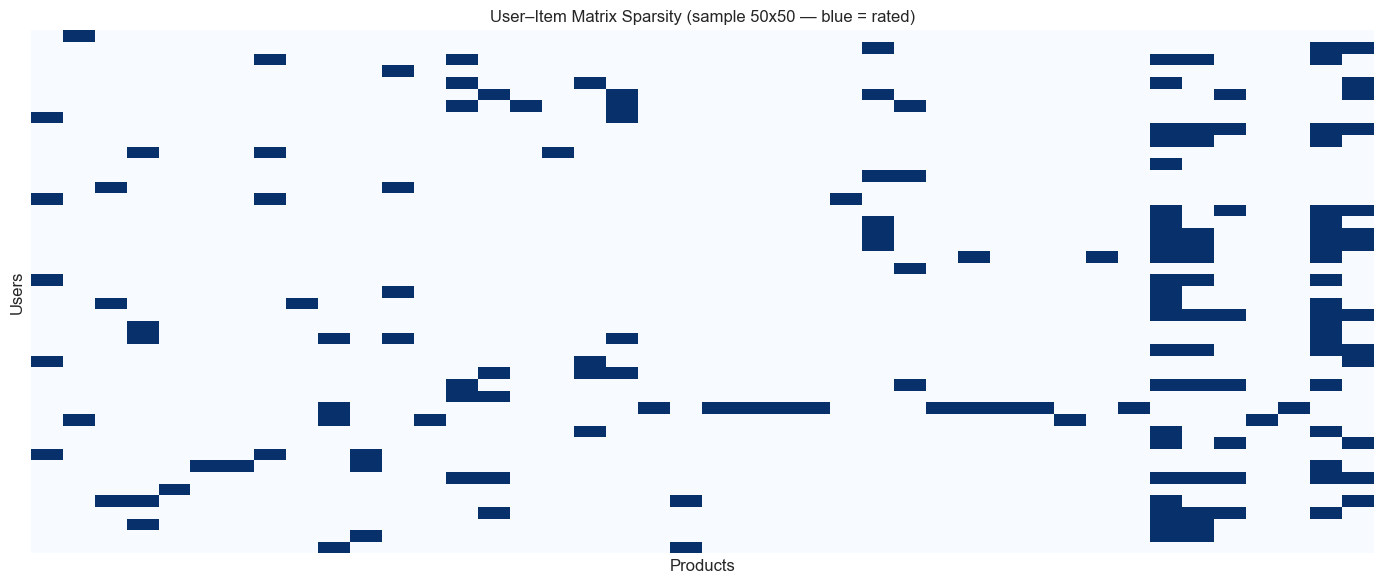

Sample sparsity: 91.38%


In [9]:
# Sample a small subset for visualisation
sample_users    = df_filtered['userId'].value_counts().head(50).index
sample_products = df_filtered['productId'].value_counts().head(50).index

sample_df = df_filtered[
    df_filtered['userId'].isin(sample_users) &
    df_filtered['productId'].isin(sample_products)
]

matrix_sample = sample_df.pivot_table(
    index='userId', columns='productId', values='rating')

plt.figure(figsize=(14, 6))
sns.heatmap(matrix_sample.notna(), cmap='Blues', cbar=False,
            xticklabels=False, yticklabels=False)
plt.title('User–Item Matrix Sparsity (sample 50x50 — blue = rated)')
plt.xlabel('Products')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

sparsity = 1 - matrix_sample.notna().sum().sum() / matrix_sample.size
print(f'Sample sparsity: {sparsity:.2%}')

## 6. Key EDA Findings

- Dataset is extremely sparse (>99%) — most users have rated very few products
- Classic long-tail distribution: a few products get most ratings, most get very few
- Rating distribution is left-skewed — users tend to rate products they like
- Cold start is a major challenge — new users/products with no history can't be recommended to
- Filtering to active users and popular products is essential before model training
- Collaborative filtering will work well for active users; content-based for cold start